# Wildfire risk: standing hazard and right now

**This notebook was written by generative AI. It's meant to show querying across sources/formats, not provide informative analysis. Take the results with a major grain of salt.**

Two questions about the same places, stacked on one map:

- **Where does it burn?** Modelled burn probability and forty years of burn perimeters.
  These barely change year to year.
- **What is happening now?** Red Flag Warnings and active fire detections, both of which
  change by the hour.

Neither alone orders attention very well. A zone with high burn probability is not
interesting on a wet day in November; a Red Flag Warning over bare rock is not interesting
either. This notebook combines them into a per-zone ranking.

| Layer                      | Source                                         | Velocity | What it tells you                                                 |
| -------------------------- | ---------------------------------------------- | -------- | ----------------------------------------------------------------- |
| **Burn probability**       | CarbonPlan Open Climate Risk, 1 km             | static   | How often this pixel burns in a modelled fire regime              |
| **Burn history**           | MTBS perimeters 1984-2024 (Source Cooperative) | static   | Whether this landscape actually has a fire regime                 |
| **Red Flag Warnings**      | NOAA/NWS active alerts API                     | minutes  | Where fire weather is happening _now_ (wind + low RH + dry fuels) |
| **Active fire detections** | NASA FIRMS (MODIS 24h)                         | hours    | Where heat signatures are being detected _now_                    |

### Unit of analysis

The **NWS fire weather zone**. That is the unit a Red Flag Warning is actually issued
for, so nothing has to be downscaled or areally interpolated on the way in.

### How it is built

Everything that can be a query is a query. The layers are DuckDB views over remote
Parquet, GeoJSON, CSV, and zipped shapefiles (see [`views.sql`](views.sql)), the joins and
the geometry work happen in SQL through the `spatial` extension, and Python is left with
the parts it is actually better at: turning raw quantities into weighted scores, drawing,
and asserting.

The state is a parameter. One state keeps every layer small enough to work
interactively -- the whole pipeline below runs in seconds once the HTTP cache is warm.

### What the score is and is not

A **triage ranking**, not a calibrated probability. The weights are a defensible starting
point, not a fitted model, and nothing here has been validated against subsequent
ignitions. Change `WEIGHTS` to match what you care about.


## Configuration

Everything tunable is here. Nothing below reads a value that is not defined in this cell.


In [1]:
# Wyoming: the most fire zones under a Red Flag Warning in the country at the time of
# writing, with active detections and a real burn history to go with them. Any two-letter
# state works -- see the caveats at the bottom about EPSG:5070 outside CONUS.
STATE = "WY"

# CONUS Albers, for anything that measures an area or a distance
EQUAL_AREA = "EPSG:5070"

# fire just outside a zone boundary still matters
NEARBY_KM = 25.0

# MODIS confidence runs 0-100
MIN_CONFIDENCE = 30

# MTBS also contains prescribed fire, which is not the same signal
WILDFIRE_ONLY = True

# how far past the state line to look for burn perimeters, in degrees
BBOX_PAD_DEG = 0.5

WEIGHTS = {
    "burn_probability": 0.25,  # modelled long-run hazard
    "warning": 0.20,  # under a Red Flag Warning right now
    "detections": 0.20,  # fire already burning inside the zone
    "intensity": 0.10,  # summed FRP, a crude intensity proxy
    "nearby_detections": 0.10,  # fire just outside the boundary
    "burned_share": 0.08,  # share of the zone burned since 1984
    "fire_frequency": 0.07,  # count of distinct historical fires
}
assert abs(sum(WEIGHTS.values()) - 1) < 1e-9, "weights should sum to 1"

In [2]:
from datetime import UTC, datetime

RUN_AT = datetime.now(UTC)
print("Run time (UTC):", RUN_AT.isoformat(timespec="seconds"))
print("State         :", STATE)

Run time (UTC): 2026-09-11T06:42:59+00:00
State         : WY


Configure the import path:


In [3]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

## Setup

First, [**download the burn probabilities**](burn_prob.ipynb).


### Pandas


In [4]:
import pandas as pd

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 60)
pd.set_option("display.width", 160)

### DuckDB

[Docs](https://duckdb.org/docs/current/guides/python/jupyter)


In [5]:
import duckdb

%load_ext sql
conn = duckdb.connect()
%sql conn --alias duckdb

Loading configurations from /Users/afeld/dev/investinopen/ptps-wildfire-demo/pyproject.toml.

Settings changed:

Config,value
autopandas,True
displaycon,False


`setup.sql` installs the extensions and configures the Source Cooperative credentials;
`views.sql` defines one view per upstream dataset. Binding the views touches every
endpoint, so the first run is slow and later ones are served from the `cache_httpfs`
cache.


In [6]:
from helpers import run_script_in_db

run_script_in_db(conn, "setup.sql")
run_script_in_db(conn, "views.sql")

## The study area

One state, materialised once. Its bounding box is what keeps every subsequent read small:
the burn-probability glob, the FIRMS CSV, and the remote MTBS Parquet are all filtered
against it rather than being pulled down whole.


In [7]:
%%sql
CREATE OR REPLACE TABLE study_area AS
SELECT stusps AS state,
    name,
    geom,
    ST_XMin(geom) AS min_lon,
    ST_YMin(geom) AS min_lat,
    ST_XMax(geom) AS max_lon,
    ST_YMax(geom) AS max_lat
FROM state_boundaries
WHERE stusps = '{{STATE}}';

SELECT * EXCLUDE geom FROM study_area;


,state,NAME,min_lon,min_lat,max_lon,max_lat
0,WY,Wyoming,-111.056888,40.996346,-104.052287,45.005904


The fire weather zones are the rows everything else will be attached to. They are stored
twice: once in lon/lat for drawing, once in an equal-area projection for measuring.


In [8]:
%%sql
CREATE OR REPLACE TABLE zones AS
SELECT state || 'Z' || zone AS zone_id,
    name AS zone_name,
    state,
    cwa AS forecast_office,
    geom,
    reproject(geom, 'EPSG:4269', '{{EQUAL_AREA}}') AS geom_ea,
    ST_Area(reproject(geom, 'EPSG:4269', '{{EQUAL_AREA}}')) AS zone_area_m2
FROM fire_zones
WHERE state = '{{STATE}}';

SELECT count(*) AS zones,
    round(sum(zone_area_m2) / 1e6) AS total_km2,
    round(median(zone_area_m2) / 1e6) AS median_km2
FROM zones;


,zones,total_km2,median_km2
0,43,252079.0,4953.0


## Layer 1 - Burn probability

CarbonPlan's Open Climate Risk burn probability, on a 1 km grid, downloaded by
[`burn_prob.ipynb`](burn_prob.ipynb). `bp_2011` is the modelled annual probability that a
given pixel burns. The values are small -- a 1% annual chance is a lot of fire over a
thirty-year mortgage.

Each map below renders twice: a static image so it shows up in file previews (GitHub,
nbviewer), then an interactive [Folium](https://python-visualization.github.io/folium/)
map wherever the notebook frontend executes the embedded scripts.


In [9]:
%%sql
CREATE OR REPLACE TABLE burn_prob AS
SELECT bp.longitude,
    bp.latitude,
    bp.bp_2011,
    bp.point,
    reproject(ST_Point(bp.longitude, bp.latitude), 'EPSG:4326', '{{EQUAL_AREA}}') AS point_ea
FROM burn_prob_1km AS bp,
    study_area AS s
WHERE bp.bp_2011 IS NOT NULL
    AND NOT isnan(bp.bp_2011)
    -- the raster is CONUS-wide; the bounding box is what makes this cheap
    AND bp.longitude BETWEEN s.min_lon AND s.max_lon
    AND bp.latitude BETWEEN s.min_lat AND s.max_lat;

SELECT count(*) AS cells,
    round(avg(bp_2011), 5) AS mean_bp,
    round(max(bp_2011), 4) AS max_bp
FROM burn_prob;


,cells,mean_bp,max_bp
0,271466,0.00217,0.0191


https://jupysql.readthedocs.io/en/docs/plot.html#histogram


Text(0.5, 1.0, 'Burn probability distribution, WY')

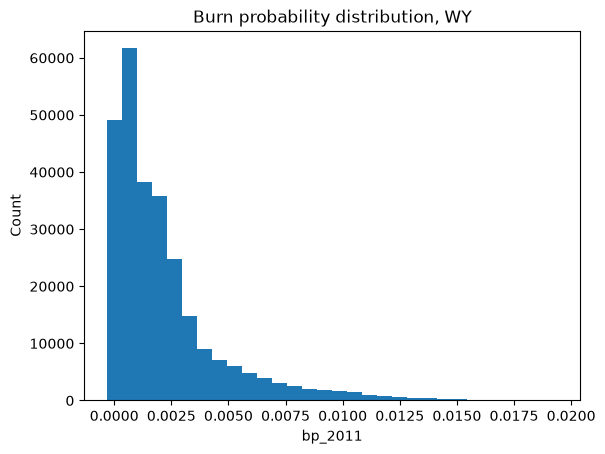

In [10]:
ax = %sqlplot histogram --table burn_prob --column bp_2011 --bins 30
ax.set_title(f"Burn probability distribution, {STATE}")

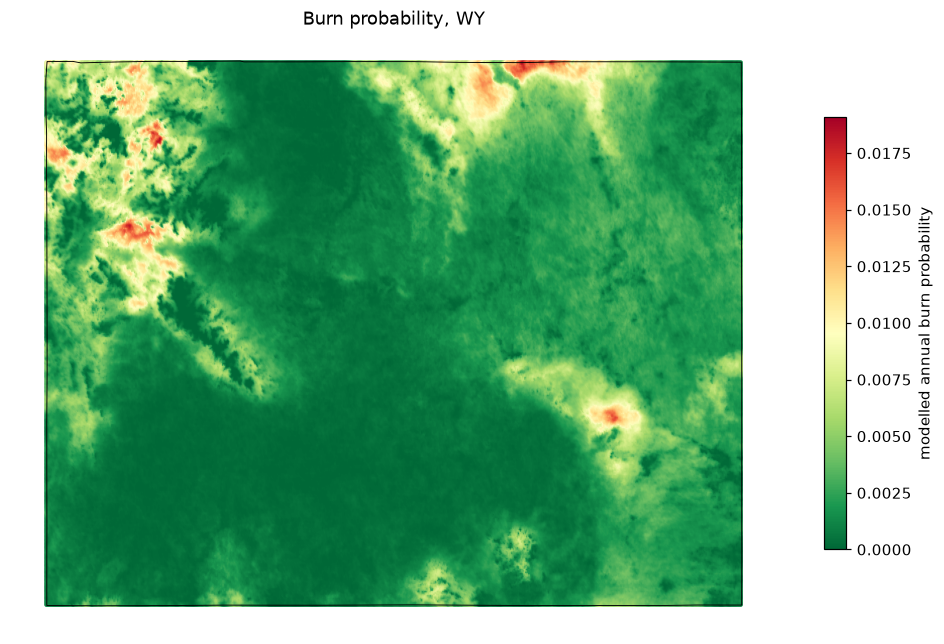

In [11]:
import folium
import matplotlib.pyplot as plt
import numpy as np
from helpers import read_geo, render_map

state_outline = read_geo(
    conn, "SELECT ST_AsText(geom) AS geom FROM study_area", crs="EPSG:4269"
)
burn_prob_points = conn.execute(
    "SELECT longitude, latitude, bp_2011 FROM burn_prob"
).df()

# static fallback (rendered in every preview, GitHub included)
fig, ax = plt.subplots(figsize=(9, 6))
state_outline.boundary.plot(ax=ax, color="black", linewidth=0.6)
scatter = ax.scatter(
    burn_prob_points["longitude"],
    burn_prob_points["latitude"],
    c=burn_prob_points["bp_2011"],
    # match the Wildfire Hazard Potential colour scheme, to compare
    # https://experience.arcgis.com/experience/78e7e78bcef64dfc98cf13e2e0eae156
    cmap="RdYlGn_r",
    s=6,
    linewidths=0,
)
fig.colorbar(scatter, ax=ax, shrink=0.7, label="modelled annual burn probability")
ax.set_title(f"Burn probability, {STATE}")
ax.set_axis_off()
fig.tight_layout()

# interactive: 270k+ points is too many for individual Folium markers, so they're
# rasterised to a transparent image and draped over a pannable basemap at their own
# extent, rather than reinterpreted as a density heatmap
overlay_bounds = (
    burn_prob_points["longitude"].min(),
    burn_prob_points["latitude"].min(),
    burn_prob_points["longitude"].max(),
    burn_prob_points["latitude"].max(),
)
overlay_fig, overlay_ax = plt.subplots(figsize=(8, 8), dpi=150)
overlay_ax.scatter(
    burn_prob_points["longitude"],
    burn_prob_points["latitude"],
    c=burn_prob_points["bp_2011"],
    cmap="RdYlGn_r",
    s=8,
    linewidths=0,
)
overlay_ax.set_xlim(overlay_bounds[0], overlay_bounds[2])
overlay_ax.set_ylim(overlay_bounds[1], overlay_bounds[3])
overlay_ax.axis("off")
overlay_ax.set_position((0, 0, 1, 1))
overlay_fig.canvas.draw()
overlay_image = np.asarray(overlay_fig.canvas.buffer_rgba())
plt.close(overlay_fig)

m = folium.Map()
m.fit_bounds(
    [[overlay_bounds[1], overlay_bounds[0]], [overlay_bounds[3], overlay_bounds[2]]]
)
folium.raster_layers.ImageOverlay(
    overlay_image,
    bounds=[
        [overlay_bounds[1], overlay_bounds[0]],
        [overlay_bounds[3], overlay_bounds[2]],
    ],
    opacity=0.75,
).add_to(m)
folium.GeoJson(
    state_outline,
    style_function=lambda _: {"color": "black", "weight": 1, "fillOpacity": 0},
).add_to(m)
render_map(fig, m)

## Layer 2 - Burn history

MTBS perimeters, 1984-2024, read straight off Source Cooperative. The file covers the
whole country and is far too big to download, so the query prunes to nine columns and
filters on the perimeter centroid before any geometry is decoded.

DuckDB reads the GeoParquet metadata itself, so `geom` arrives as a typed
`GEOMETRY('OGC:CRS84')` -- no WKB decoding and no guessing at the projection.


In [12]:
%%sql
CREATE OR REPLACE TABLE burn_history AS
SELECT m.event_id,
    m.incident,
    m.incid_type,
    m.acres,
    m.ig_date,
    m.ig_year,
    m.geom,
    reproject(m.geom, 'EPSG:4326', '{{EQUAL_AREA}}') AS geom_ea
FROM mtbs_perimeters AS m,
    study_area AS s
WHERE m.centroid_lon BETWEEN s.min_lon - {{BBOX_PAD_DEG}} AND s.max_lon + {{BBOX_PAD_DEG}}
    AND m.centroid_lat BETWEEN s.min_lat - {{BBOX_PAD_DEG}} AND s.max_lat + {{BBOX_PAD_DEG}}
    AND (
        NOT {{WILDFIRE_ONLY}}
        OR m.incid_type NOT ILIKE '%prescribed%'
    );

SELECT count(*) AS perimeters,
    min(ig_year) AS first_year,
    max(ig_year) AS last_year,
    round(sum(acres) / 1e6, 2) AS million_acres
FROM burn_history;


,perimeters,first_year,last_year,million_acres
0,688,1984,2024,7.45


In [13]:
%%sql
SELECT ig_year, count(*) AS fires, round(sum(acres)) AS acres
FROM burn_history
GROUP BY ig_year
ORDER BY acres DESC
LIMIT 10;


,ig_year,fires,acres
0,1988,49,1738595.0
1,2012,52,689121.0
2,2020,21,627929.0
3,2024,27,579914.0
4,2000,48,539722.0
5,2016,32,336263.0
6,2006,37,333274.0
7,1996,35,313778.0
8,2018,23,278395.0
9,2002,30,219960.0


## Layer 3 - Red Flag Warnings

The NWS alerts endpoint returns CAP alerts wrapped in GeoJSON, and most Red Flag Warnings
carry `geometry: null` -- they are issued _for a zone_, not for an ad-hoc polygon. Code
that reads the feature's own geometry silently drops most of the warnings. The
`red_flag_zones` view in [`views.sql`](views.sql) explodes `affectedZones` and joins each
one to its shape from the fire zone shapefile.

The same zone can be covered by more than one alert, so they are collapsed back to one row
per zone here.


In [14]:
%%sql
CREATE OR REPLACE TABLE warnings AS
SELECT zone_id,
    count(DISTINCT id) AS n_alerts,
    string_agg(DISTINCT event, ', ') AS events,
    max(severity) AS severity,
    max(expires) AS expires,
    max(headline) AS headline,
    string_agg(DISTINCT senderName, ', ') AS offices
FROM red_flag_zones
WHERE zone_state = '{{STATE}}'
GROUP BY zone_id;

SELECT count(*) AS warned_zones,
    (SELECT count(*) FROM zones) AS zones_in_state,
    min(expires) AS first_expiry,
    max(expires) AS last_expiry
FROM warnings;


,warned_zones,zones_in_state,first_expiry,last_expiry
0,6,43,2026-09-11 07:00:00-05:00,2026-09-11 20:00:00-05:00


If that came back empty, it is a real answer rather than a failure: Red Flag Warnings are
seasonal, and often absent overnight. Every step below still runs -- the warning component
just scores zero for every zone, and the ranking falls back to standing hazard. Try again
during afternoon peak wind, or point `STATE` somewhere drier.


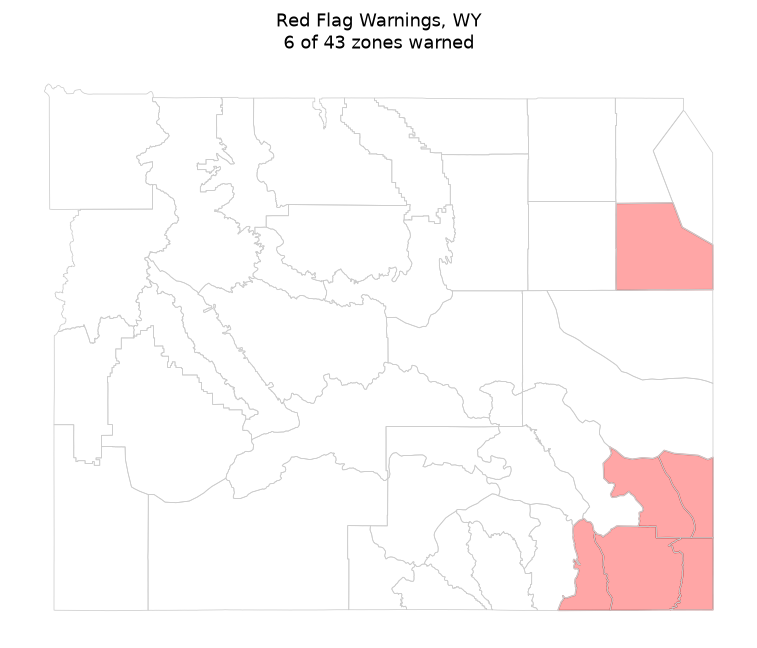

In [15]:
import folium

zone_outlines = read_geo(
    conn, "SELECT ST_AsText(geom) AS geom FROM zones", crs="EPSG:4269"
)
warned = read_geo(
    conn,
    "SELECT z.zone_id, ST_AsText(z.geom) AS geom "
    "FROM zones AS z JOIN warnings AS w USING (zone_id)",
    crs="EPSG:4269",
)

fig, ax = plt.subplots(figsize=(9, 6))
zone_outlines.boundary.plot(ax=ax, color="0.8", linewidth=0.5)
if not warned.empty:
    warned.plot(ax=ax, facecolor="red", edgecolor="darkred", alpha=0.35)
ax.set_title(
    f"Red Flag Warnings, {STATE}\n{len(warned)} of {len(zone_outlines)} zones warned"
)
ax.set_axis_off()
fig.tight_layout()

# interactive: the dissolved warning polygons, when there are any
interactive = None
if not warned.empty:
    warning_areas = read_geo(
        conn, "SELECT ST_AsText(geom) AS geom FROM red_flag_warnings", crs="EPSG:4269"
    )
    bounds = zone_outlines.total_bounds
    interactive = folium.Map()
    interactive.fit_bounds([[bounds[1], bounds[0]], [bounds[3], bounds[2]]])
    folium.GeoJson(
        zone_outlines,
        style_function=lambda _: {"color": "#999999", "weight": 0.5, "fillOpacity": 0},
    ).add_to(interactive)
    folium.GeoJson(
        warning_areas,
        style_function=lambda _: {
            "color": "darkred",
            "weight": 1,
            "fillColor": "red",
            "fillOpacity": 0.35,
        },
    ).add_to(interactive)
render_map(fig, interactive)

## Layer 4 - Active fire detections

> Each MODIS active fire/thermal hotspot location represents the center of a 1km pixel
> that is flagged by the algorithm as containing one or more fires within the pixel.

- https://www.earthdata.nasa.gov/data/tools/firms
- https://firms.modaps.eosdis.nasa.gov/active_fire/#firms-txt

A detection is a **thermal anomaly**, not a confirmed wildfire. Gas flares, industrial
heat, and agricultural burning all show up. The bounding box is padded by a degree,
because fire on the other side of the state line is still worth counting as nearby.


In [16]:
%%sql
CREATE OR REPLACE TABLE detections AS
SELECT f.latitude,
    f.longitude,
    f.acq_date,
    f.acq_time,
    f.confidence,
    f.frp,
    f.daynight,
    ST_Point(f.longitude, f.latitude) AS point,
    reproject(ST_Point(f.longitude, f.latitude), 'EPSG:4326', '{{EQUAL_AREA}}') AS point_ea
FROM active_fires AS f,
    study_area AS s
WHERE f.longitude BETWEEN s.min_lon - 1 AND s.max_lon + 1
    AND f.latitude BETWEEN s.min_lat - 1 AND s.max_lat + 1
    AND f.confidence >= {{MIN_CONFIDENCE}};

SELECT count(*) AS detections,
    round(sum(frp)) AS total_frp_mw,
    min(acq_date) AS earliest,
    max(acq_date) AS latest
FROM detections;


,detections,total_frp_mw,earliest,latest
0,38,1630.0,2026-09-10,2026-09-11


## Combining the layers

One query attaches all four layers to each zone. It is written as a function of its input
table names so the smoke test at the bottom can run the exact same SQL against fixtures.

Three details worth pointing at:

- Areas and distances are computed in `EQUAL_AREA`, never in degrees.
- `ST_Union_Agg` dissolves the burned pieces before measuring them, so a reburn of the
  same footprint counts as two fires but is only measured once.
- Every count is zero-filled rather than left NULL, so a zone with no fire and no warning
  is still a row.


In [17]:
def zone_metrics_sql(
    zones="zones",
    detections="detections",
    burn_history="burn_history",
    burn_prob="burn_prob",
    warnings="warnings",
    nearby_m=None,
) -> str:
    """SQL attaching every layer to each zone. Parameterised so fixtures can be swapped in."""
    nearby_m = NEARBY_KM * 1000 if nearby_m is None else nearby_m
    return f"""
WITH inside AS (
    SELECT z.zone_id, count(*) AS n_detections, sum(d.frp) AS frp_sum
    FROM {zones} AS z
    JOIN {detections} AS d ON ST_Contains(z.geom_ea, d.point_ea)
    GROUP BY z.zone_id
),
nearby AS (
    SELECT z.zone_id, count(*) AS n_detections_nearby
    FROM {zones} AS z
    JOIN {detections} AS d ON ST_DWithin(z.geom_ea, d.point_ea, {nearby_m})
    GROUP BY z.zone_id
),
burn_overlaps AS (
    SELECT z.zone_id, h.event_id, h.ig_year,
        ST_Intersection(z.geom_ea, h.geom_ea) AS piece
    FROM {zones} AS z
    JOIN {burn_history} AS h ON ST_Intersects(z.geom_ea, h.geom_ea)
),
history AS (
    SELECT zone_id,
        count(DISTINCT event_id) AS n_hist_fires,
        max(ig_year) AS last_burn_year,
        -- dissolve first, so overlapping reburns aren't double counted
        ST_Area(ST_Union_Agg(piece)) AS burned_m2
    FROM burn_overlaps
    GROUP BY zone_id
),
hazard AS (
    SELECT z.zone_id,
        avg(b.bp_2011) AS mean_burn_prob,
        max(b.bp_2011) AS max_burn_prob,
        count(*) AS n_bp_cells
    FROM {zones} AS z
    JOIN {burn_prob} AS b ON ST_Contains(z.geom_ea, b.point_ea)
    GROUP BY z.zone_id
)
SELECT z.zone_id,
    z.zone_name,
    z.state,
    z.forecast_office,
    z.zone_area_m2,
    w.zone_id IS NOT NULL AS under_warning,
    coalesce(w.n_alerts, 0) AS n_alerts,
    w.events,
    w.severity,
    w.expires,
    w.headline,
    w.offices,
    coalesce(i.n_detections, 0) AS n_detections,
    coalesce(i.frp_sum, 0) AS frp_sum,
    coalesce(n.n_detections_nearby, 0) AS n_detections_nearby,
    coalesce(h.n_hist_fires, 0) AS n_hist_fires,
    h.last_burn_year,
    least(coalesce(h.burned_m2, 0) / z.zone_area_m2, 1.0) AS burned_frac,
    coalesce(hz.mean_burn_prob, 0) AS mean_burn_prob,
    coalesce(hz.max_burn_prob, 0) AS max_burn_prob,
    coalesce(hz.n_bp_cells, 0) AS n_bp_cells,
    z.geom
FROM {zones} AS z
LEFT JOIN {warnings} AS w USING (zone_id)
LEFT JOIN inside AS i USING (zone_id)
LEFT JOIN nearby AS n USING (zone_id)
LEFT JOIN history AS h USING (zone_id)
LEFT JOIN hazard AS hz USING (zone_id)
"""


conn.execute(f"CREATE OR REPLACE TABLE zone_metrics AS {zone_metrics_sql()}")

print(
    f"{conn.execute('SELECT count(*) FROM zone_metrics').fetchone()[0]} zones measured"
)

43 zones measured


In [18]:
%%sql
SELECT zone_id,
    zone_name,
    under_warning,
    n_detections,
    round(frp_sum) AS frp,
    n_detections_nearby,
    n_hist_fires,
    round(burned_frac * 100, 1) AS burned_pct,
    round(mean_burn_prob * 1000, 2) AS burn_prob_per_1k,
    last_burn_year
FROM zone_metrics
ORDER BY under_warning DESC, n_detections DESC, mean_burn_prob DESC
LIMIT 15;


,zone_id,zone_name,under_warning,n_detections,frp,n_detections_nearby,n_hist_fires,burned_pct,burn_prob_per_1k,last_burn_year
0,WYZ429,Southern Laramie Range,True,0,0.0,0,0,0.0,2.75,<NA>
1,WYZ432,Bordeaux/Chugwater/Wheatland,True,0,0.0,26,2,1.8,2.69,2021
2,WYZ317,Weston County Plains,True,0,0.0,0,19,5.3,2.44,2024
3,WYZ430,Laramie Foothills and High Plains,True,0,0.0,0,4,1.2,2.33,2024
4,WYZ433,Goshen/Middle-Lower North Platte River Basin,True,0,0.0,0,1,0.0,1.61,2024
5,WYZ431,Laramie East High Plains,True,0,0.0,0,1,0.0,1.26,2024
6,WYZ419,North Laramie Range and Adjacent High Plains,False,26,1386.0,26,19,14.7,4.84,2018
7,WYZ286,Absaroka Mountains/North Shoshone NF,False,1,17.0,1,29,14.9,3.36,2019
8,WYZ418,Middle North Platte River Basin/Niobrara and Converse Hi...,False,1,25.0,1,35,8.7,3.14,2024
9,WYZ274,Sheridan County/Casper BLM,False,0,0.0,0,27,13.1,7.68,2024


## Scoring

Two steps kept deliberately apart: `score_components` turns raw quantities into comparable
0-1 numbers, and `rank_zones` applies the weights. So you can inspect the components,
reweight without recomputing anything spatial, or drop a component by editing `WEIGHTS`.

Counts are scaled on a log axis because they are heavily tailed -- one zone with forty
detections should not flatten every other zone to nothing.


In [19]:
import numpy as np


def scale01(values, log: bool = False) -> pd.Series:
    """Min-max to [0,1]; log1p first for heavy-tailed counts. All-equal -> all zeros."""
    s = pd.to_numeric(pd.Series(values), errors="coerce").fillna(0.0).astype(float)
    if log:
        s = np.log1p(s.clip(lower=0))
    lo, hi = s.min(), s.max()
    if not np.isfinite(lo) or not np.isfinite(hi) or hi <= lo:
        return pd.Series(0.0, index=s.index)
    return (s - lo) / (hi - lo)


def score_components(zones: pd.DataFrame) -> pd.DataFrame:
    """Raw quantities -> comparable 0-1 components."""

    def col(name):
        return (
            zones[name] if name in zones.columns else pd.Series(0.0, index=zones.index)
        )

    return pd.DataFrame(
        {
            "burn_probability": scale01(col("mean_burn_prob")),
            # already 0/1, and scale01 would blow it up to the full range whenever any
            # zone is warned
            "warning": col("under_warning").astype(float),
            "detections": scale01(col("n_detections"), log=True),
            "intensity": scale01(col("frp_sum"), log=True),
            "nearby_detections": scale01(col("n_detections_nearby"), log=True),
            "burned_share": scale01(col("burned_frac")),
            "fire_frequency": scale01(col("n_hist_fires"), log=True),
        },
        index=zones.index,
    )


def rank_zones(zones: pd.DataFrame, weights: dict) -> pd.DataFrame:
    """Weighted composite on a 0-100 scale, with each contribution kept as `c_*`."""
    if zones.empty:
        return zones
    out = zones.copy()
    components = score_components(out)
    for name, weight in weights.items():
        out[f"c_{name}"] = components[name] * weight
    out["score"] = (components * pd.Series(weights)).sum(axis=1) * 100
    out["years_since_burn"] = RUN_AT.year - out["last_burn_year"]
    out = out.sort_values("score", ascending=False).reset_index(drop=True)
    out["rank"] = np.arange(1, len(out) + 1)
    return out

In [20]:
metrics = conn.execute("SELECT * EXCLUDE geom FROM zone_metrics").df()
ranked = rank_zones(metrics, WEIGHTS)

# hand the scores back to DuckDB so the geometry can be joined to them in SQL
conn.register("ranked_df", ranked)
conn.execute("""
CREATE OR REPLACE TABLE zone_ranks AS
SELECT r.*, z.geom
FROM ranked_df AS r
JOIN zones AS z USING (zone_id)
""")

print(
    f"Scored {len(ranked)} zones. Range {ranked['score'].min():.1f}-{ranked['score'].max():.1f}."
)
print("Weights:", ", ".join(f"{k} {v:.0%}" for k, v in WEIGHTS.items()))

Scored 43 zones. Range 2.5-62.8.
Weights: burn_probability 25%, warning 20%, detections 20%, intensity 10%, nearby_detections 10%, burned_share 8%, fire_frequency 7%


## The answer

Read the score as a queue order, not a probability.

One deliberate asymmetry worth naming: `years_since_burn` is reported but **not scored**.
A landscape that burned two years ago is often _less_ dangerous in the short term, because
the fuel is gone. Frequency and extent of past fire indicate a fire-prone regime; recency
cuts the other way. Folding both into one number would hide that tension, so recency stays
a column you read alongside the rank.


In [21]:
%%sql
SELECT rank,
    zone_id,
    zone_name,
    round(score, 1) AS score,
    under_warning,
    n_detections,
    round(frp_sum) AS frp,
    n_detections_nearby,
    round(mean_burn_prob * 1000, 2) AS burn_prob_per_1k,
    round(burned_frac * 100, 1) AS burned_pct,
    n_hist_fires,
    years_since_burn
FROM zone_ranks
ORDER BY rank
LIMIT 20;


,rank,zone_id,zone_name,score,under_warning,n_detections,frp,n_detections_nearby,burn_prob_per_1k,burned_pct,n_hist_fires,years_since_burn
0,1,WYZ419,North Laramie Range and Adjacent High Plains,62.8,False,26,1386.0,26,4.84,14.7,19,8
1,2,WYZ432,Bordeaux/Chugwater/Wheatland,40.3,True,0,0.0,26,2.69,1.8,2,5
2,3,WYZ140,Yellowstone National Park,35.2,False,0,0.0,0,6.25,54.8,53,6
3,4,WYZ317,Weston County Plains,33.3,True,0,0.0,0,2.44,5.3,19,2
4,5,WYZ274,Sheridan County/Casper BLM,32.8,False,0,0.0,0,7.68,13.1,27,2
5,6,WYZ430,Laramie Foothills and High Plains,29.8,True,0,0.0,0,2.33,1.2,4,2
6,7,WYZ286,Absaroka Mountains/North Shoshone NF,28.8,False,1,17.0,1,3.36,14.9,29,7
7,8,WYZ429,Southern Laramie Range,28.3,True,0,0.0,0,2.75,0.0,0,<NA>
8,9,WYZ418,Middle North Platte River Basin/Niobrara and Converse Hi...,28.0,False,1,25.0,1,3.14,8.7,35,2
9,10,WYZ433,Goshen/Middle-Lower North Platte River Basin,25.6,True,0,0.0,0,1.61,0.0,1,2


In [22]:
def describe_hot_zones(ranked: pd.DataFrame, n: int = 5) -> list[str]:
    """One plain-language line per zone that is both warned and actively burning."""
    hot = ranked[(ranked["n_detections"] > 0) & ranked["under_warning"]].head(n)
    return [
        f"{r.zone_name} ({r.zone_id}): {int(r.n_detections)} detections, "
        f"{r.frp_sum:.0f} MW, {r.burned_frac:.0%} of the zone burned since 1984, "
        f"warning expires {r.expires:%b %d %H:%M} UTC"
        for r in hot.itertuples()
    ]


hot = describe_hot_zones(ranked)
print(f"{int((ranked['n_detections'] > 0).sum())} zones have detections inside them.")
print(f"{int(ranked['under_warning'].sum())} zones are under a Red Flag Warning.")
print(f"{len(hot)} are both:\n")
for line in hot:
    print(f"  - {line}")

3 zones have detections inside them.
6 zones are under a Red Flag Warning.
0 are both:



### What put each zone where it is

The stacked bars are the weighted contributions, so the segments add up to the score
itself. A tall bar made entirely of blue is a standing-hazard zone; one with a lot of red
is burning right now.


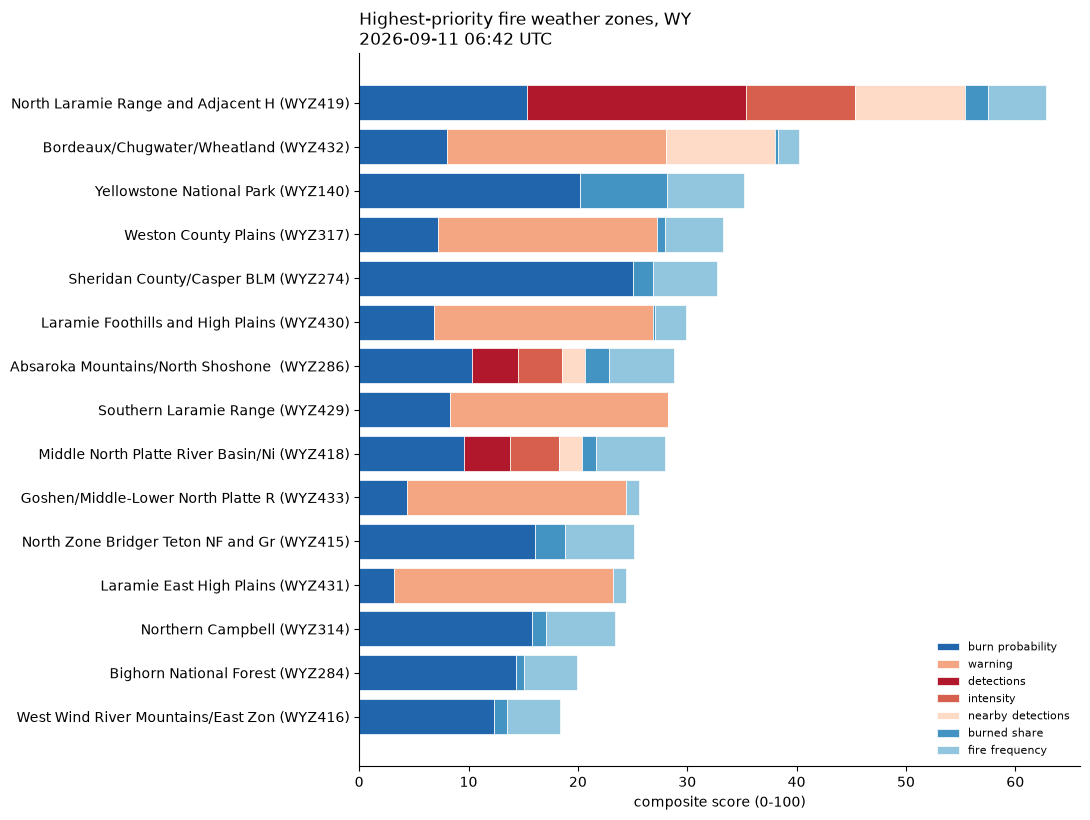

In [23]:
import matplotlib.pyplot as plt

COMPONENT_COLORS = {
    "burn_probability": "#2166ac",
    "warning": "#f4a582",
    "detections": "#b2182b",
    "intensity": "#d6604d",
    "nearby_detections": "#fddbc7",
    "burned_share": "#4393c3",
    "fire_frequency": "#92c5de",
}


def plot_score_breakdown(ranked, weights, run_at, state, n=15, ax=None):
    if ranked.empty:
        return None
    top = ranked.head(min(n, len(ranked))).iloc[::-1]
    labels = [f"{r.zone_name[:34]} ({r.zone_id})" for r in top.itertuples()]

    if ax is None:
        _, ax = plt.subplots(figsize=(11, 0.42 * len(top) + 2))
    left = np.zeros(len(top))
    for name in weights:
        values = (top[f"c_{name}"] * 100).values
        ax.barh(
            labels,
            values,
            left=left,
            label=name.replace("_", " "),
            color=COMPONENT_COLORS[name],
            edgecolor="white",
            linewidth=0.5,
        )
        left += values

    ax.set_xlabel("composite score (0-100)")
    ax.set_title(
        f"Highest-priority fire weather zones, {state}\n"
        f"{run_at.strftime('%Y-%m-%d %H:%M')} UTC",
        loc="left",
        fontsize=12,
    )
    ax.legend(loc="lower right", fontsize=8, frameon=False)
    ax.spines[["top", "right"]].set_visible(False)
    return ax


plot_score_breakdown(ranked, WEIGHTS, RUN_AT, STATE)
plt.tight_layout()
plt.show()

### On the map

Zones shaded by score, with the active detections on top.


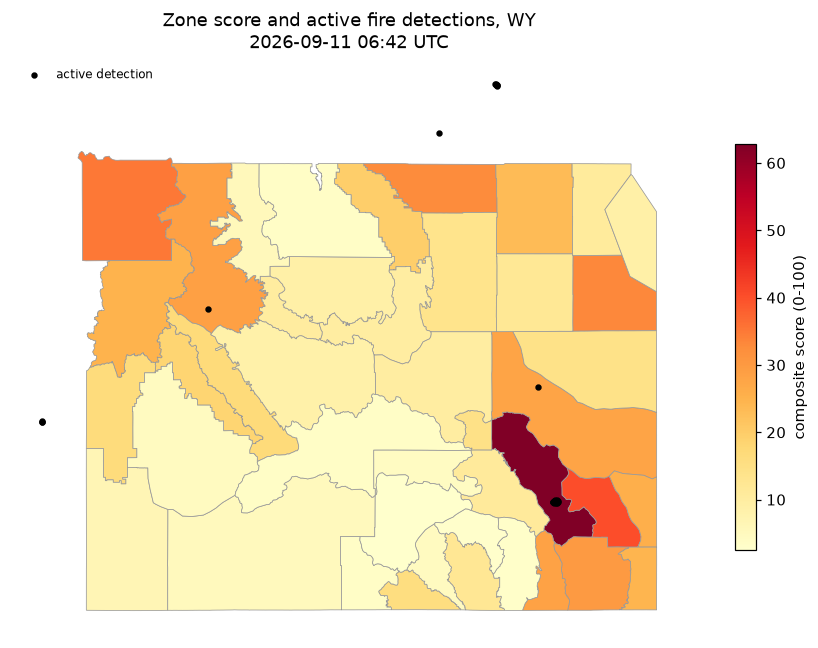

In [24]:
import folium
from helpers import to_hex_color_map

ranked_zones = read_geo(
    conn,
    "SELECT zone_id, zone_name, score, under_warning, n_detections, n_hist_fires, "
    "ST_AsText(geom) AS geom FROM zone_ranks",
    crs="EPSG:4269",
)
detection_points = conn.execute(
    "SELECT latitude, longitude, frp, acq_date, confidence FROM detections"
).df()

fig, ax = plt.subplots(figsize=(9, 6))
ranked_zones.plot(
    ax=ax,
    column="score",
    cmap="YlOrRd",
    legend=True,
    edgecolor="0.6",
    linewidth=0.5,
    legend_kwds={"label": "composite score (0-100)", "shrink": 0.7},
)
if not detection_points.empty:
    ax.scatter(
        detection_points["longitude"],
        detection_points["latitude"],
        s=10,
        color="black",
        label="active detection",
    )
    ax.legend(loc="upper left", fontsize=8, frameon=False)
ax.set_title(
    f"Zone score and active fire detections, {STATE}\n{RUN_AT:%Y-%m-%d %H:%M} UTC"
)
ax.set_axis_off()
fig.tight_layout()

# interactive: zones coloured by score, with the active detections on top
zone_colors = dict(
    zip(ranked_zones["zone_id"], to_hex_color_map(ranked_zones["score"], "YlOrRd"))
)
bounds = ranked_zones.total_bounds
m = folium.Map()
m.fit_bounds([[bounds[1], bounds[0]], [bounds[3], bounds[2]]])
folium.GeoJson(
    ranked_zones,
    style_function=lambda f: {
        "fillColor": zone_colors[f["properties"]["zone_id"]],
        "color": "#787878",
        "weight": 1,
        "fillOpacity": 0.7,
    },
    tooltip=folium.GeoJsonTooltip(
        fields=["zone_name", "score", "n_detections", "n_hist_fires"],
        aliases=["zone", "score", "detections", "historical fires"],
    ),
).add_to(m)
for row in detection_points.itertuples():
    folium.CircleMarker(
        location=[row.latitude, row.longitude],
        radius=3,
        color="#141414",
        fill=True,
        fill_opacity=1,
        tooltip=f"{row.frp:.0f} MW, {row.acq_date}, confidence {row.confidence}",
    ).add_to(m)
render_map(fig, m)

## Smoke test

The metrics query is the part most likely to break silently -- an empty overlay from a
projection mismatch, or a dissolve that stops dissolving, both look like a plausible
ranking rather than an error. This builds fixture tables with known answers and runs the
_same SQL_ over them.

It needs no network and takes about a second. Run it after editing anything above.


In [25]:
def make_fixtures(conn) -> None:
    """Four zones in a row, with a known number of detections and a known burned area."""
    conn.execute(f"""
    CREATE OR REPLACE TABLE t_zones AS
    SELECT zone_id, zone_name, 'CA' AS state, 'TST' AS forecast_office,
        geom, reproject(geom, 'EPSG:4326', '{EQUAL_AREA}') AS geom_ea,
        ST_Area(reproject(geom, 'EPSG:4326', '{EQUAL_AREA}')) AS zone_area_m2
    FROM (
        SELECT 'TSTZ' || k AS zone_id, 'Test zone ' || k AS zone_name,
            ST_GeomFromText(
                'POLYGON((' || (-122 + k) || ' 36, ' || (-122 + k + 0.6) || ' 36, '
                || (-122 + k + 0.6) || ' 36.6, ' || (-122 + k) || ' 36.6, '
                || (-122 + k) || ' 36))'
            ) AS geom
        FROM range(4) AS t(k)
    );

    -- counts[k] detections inside zone k: 0, 1, 3, 5
    CREATE OR REPLACE TABLE t_detections AS
    SELECT 10.0 * (i + 1) AS frp,
        reproject(ST_Point(-122 + c.k + 0.1 + 0.05 * i, 36.3), 'EPSG:4326', '{EQUAL_AREA}') AS point_ea
    FROM (VALUES (0, 0), (1, 1), (2, 3), (3, 5)) AS c(k, n),
        range(5) AS t(i)
    WHERE i < c.n;

    -- one fire covering a quarter of zone 3, plus a reburn of the same footprint
    CREATE OR REPLACE TABLE t_history AS
    SELECT event_id, ig_year,
        reproject(
            ST_GeomFromText('POLYGON((-119 36, -118.7 36, -118.7 36.3, -119 36.3, -119 36))'),
            'EPSG:4326', '{EQUAL_AREA}'
        ) AS geom_ea
    FROM (VALUES ('A', 1995), ('B', 2015)) AS f(event_id, ig_year);

    -- a constant field, except the eastern end (zone 3) which is hotter
    CREATE OR REPLACE TABLE t_burn_prob AS
    SELECT CASE WHEN lon > -119.4 THEN 0.02 ELSE 0.001 END AS bp_2011,
        reproject(ST_Point(lon, 36.3), 'EPSG:4326', '{EQUAL_AREA}') AS point_ea
    FROM (SELECT -121.9 + 0.1 * i AS lon FROM range(40) AS t(i));

    CREATE OR REPLACE TABLE t_warnings AS
    SELECT 'TSTZ3' AS zone_id, 1 AS n_alerts, 'Red Flag Warning' AS events,
        'Severe' AS severity, TIMESTAMPTZ '2030-01-01 00:00:00Z' AS expires,
        'test' AS headline, 'NWS Test' AS offices;
    """)


def run_smoke_test(conn, weights) -> None:
    make_fixtures(conn)
    sql = zone_metrics_sql(
        zones="t_zones",
        detections="t_detections",
        burn_history="t_history",
        burn_prob="t_burn_prob",
        warnings="t_warnings",
    )
    m = conn.execute(f"{sql} ORDER BY zone_id").df()

    # scale01
    assert scale01([0, 0, 0]).tolist() == [0.0, 0.0, 0.0], (
        "constant input must give zeros"
    )
    assert scale01([0, 5, 10]).tolist() == [0.0, 0.5, 1.0]

    # the detection join
    assert m["n_detections"].tolist() == [0, 1, 3, 5], m["n_detections"].tolist()
    assert m.loc[m.zone_id == "TSTZ0", "frp_sum"].iloc[0] == 0
    assert m.loc[m.zone_id == "TSTZ2", "frp_sum"].iloc[0] == 60.0  # 10 + 20 + 30

    # the burn overlay: two overlapping fires, one footprint
    hit = m[m.zone_id == "TSTZ3"].iloc[0]
    assert hit.n_hist_fires == 2, "distinct fires should be counted separately"
    assert 0.2 < hit.burned_frac < 0.3, f"dissolve failed, got {hit.burned_frac:.3f}"
    assert hit.last_burn_year == 2015
    assert m[m.zone_id == "TSTZ0"].iloc[0].burned_frac == 0

    # warnings and burn probability land on the right zones
    assert m["under_warning"].tolist() == [False, False, False, True]
    assert (
        m.loc[m.zone_id == "TSTZ3", "mean_burn_prob"].iloc[0]
        > (m.loc[m.zone_id == "TSTZ0", "mean_burn_prob"].iloc[0])
    )

    # empty inputs must not raise
    conn.execute("CREATE OR REPLACE TABLE t_none AS SELECT * FROM t_detections LIMIT 0")
    empty = conn.execute(
        zone_metrics_sql(
            zones="t_zones",
            detections="t_none",
            burn_history="t_history",
            burn_prob="t_burn_prob",
            warnings="t_warnings",
        )
    ).df()
    assert (empty["n_detections"] == 0).all()
    assert rank_zones(pd.DataFrame(columns=["zone_id"]), weights).empty

    # ranking: more fire, more history and more hazard should sort higher
    r = rank_zones(m, weights)
    assert r.iloc[0].zone_id == "TSTZ3", r[["zone_id", "score"]].to_dict("records")
    assert r.iloc[-1].zone_id == "TSTZ0"
    assert abs(r["score"].max() - 100) < 1e-6, "top zone maxes every component"

    print(
        f"smoke test passed - {len(r)} fixture zones scored "
        f"{r['score'].min():.1f}-{r['score'].max():.1f}"
    )


run_smoke_test(conn, WEIGHTS)

smoke test passed - 4 fixture zones scored 0.0-100.0


## What this does not tell you

- **A detection is not a fire.** MODIS picks up gas flares, industrial heat, and
  agricultural burning. High-ranking zones deserve a look at the FIRMS attributes and, in
  California, the AlertCalifornia camera feeds in the catalog.
- **The score is unvalidated.** The weights are a starting point, not a fitted model.
  Nothing here has been checked against subsequent ignitions.
- **Burn history cuts both ways.** Frequent past fire signals a fire-prone regime; a
  _recent_ burn usually means depleted fuel. Hence `years_since_burn` being reported
  rather than scored.
- **MTBS has a size floor and a reporting lag** -- roughly 1,000 acres in the west, 500 in
  the east, and it runs a year or more behind. Small and very recent fires are simply
  absent, so `burned_frac` is a floor.
- **Burn probability is modelled**, on a 1 km grid, and averaging it over a zone the size
  of a county throws away most of what it knows.
- **Zones are coarse.** A fire weather zone can span a hundred kilometres of very
  different terrain. Zone-level ranking says "look here", not "this ridge".
- **Geography.** `EPSG:5070` is CONUS-appropriate; areas in Alaska, Hawaii, and Puerto
  Rico will be distorted, and the no-auth FIRMS file covers only CONUS + Hawaii.
- **No exposure layer.** This ranks hazard, not consequence. Two zones with identical
  scores can differ enormously in who lives there.
- **Nothing is saved.** Two of the four layers change by the hour, so re-running this
  notebook will not reproduce an earlier ranking. Capture anything you need to keep
  yourself.

## Where to take it next, from the same catalog

- **Fuel condition** -- MODIS or Sentinel-2 NDVI as a live dryness proxy; LANDFIRE
  seasonal fuels for fuel model context. This is the biggest missing driver: the warning
  tells you the weather, not what is there to burn.
- **Exposure and vulnerability** -- CarbonPlan building-level risk, CDC/ATSDR SVI, EPA
  EJScreen, and CDC PLACES turn a hazard rank into an impact rank.
- **Downwind effects** -- NOAA HMS smoke polygons plus EPA AirNow move the question from
  "where will it burn" to "who is breathing it".
- **Response capacity** -- the OSM extract (hydrants, water lines, roads) and DOE EAGLE-I
  outage history speak to whether a place can respond.
- **Ground truth** -- WFIGS/NIFC current perimeters, to check whether detections
  correspond to a recognised, named incident.
- **Finer detections** -- a free FIRMS `MAP_KEY` upgrades the detection layer from 1 km
  MODIS to 375 m VIIRS through the Area API.

Most of these slot in as one new view in `views.sql`, one more CTE in `zone_metrics_sql`,
and one more line in `WEIGHTS`.
